In [1]:
import mne
from mne.io import read_raw
import numpy as np
import matplotlib.pyplot as plt
from os.path import join
import os
import pandas as pd
import json
from collections import defaultdict

from functions import ephy_plotting, preprocessing, analysis, io, utils

# 1. Load the dataset from a session #

In [32]:
working_path = os.path.dirname(os.getcwd())
results_path = join(working_path, "results")
behav_results_saving_path = join(results_path, "behav_results")
saving_path = join(results_path, 'lfp_epochs')
os.makedirs(saving_path, exist_ok=True)  # Create the directory if it doesn't exist
onedrive_path = utils._get_onedrive_path()

# read the json file containing the included and excluded subjects, based on the behavioral results
# included_excluded_file = join(results_path, 'final_included_subjects.json')
# with open(included_excluded_file, 'r') as file:
#     included_subjects = json.load(file)

# # keep only subjects starting with "sub":
# included_subjects = [subj for subj in included_subjects if subj.startswith('sub')]
# print(f'Included_subjects: {included_subjects}')
# onedrive_path = utils._get_onedrive_path()

# sub_dict_epochs = {}  #  Stores the epochs for each subject/session
# all_sub_session_dict = {}
# all_sub_session_dict = defaultdict(dict)  # Each missing key gets an empty dictionary

session_ID = 'sub006 DBS OFF mSST'  # choose which session to pre-process

sub = session_ID[:6]
condition = session_ID.split(' ') [1] + ' ' + session_ID.split(' ') [2]
sub_onedrive_path = join(onedrive_path, sub)
sub_onedrive_path_task = join(onedrive_path, sub, 'synced_data', session_ID)
filename = [f for f in os.listdir(sub_onedrive_path_task) if (
    f.endswith('.set') and f.startswith('SYNCHRONIZED_INTRACRANIAL'))]

if not filename:
    raise FileNotFoundError(f"No .set file found in {sub_onedrive_path_task}")

file = join(sub_onedrive_path_task, filename[0])

if not os.path.isfile(file):
    raise FileNotFoundError(f"File does not exist: {file}")

print(f"Loading file: {file}")

raw = read_raw(file, preload=True)


Loading file: c:\Users\Juliette\OneDrive - Charité - Universitätsmedizin Berlin\DATA\sub006\synced_data\sub006 DBS OFF mSST\SYNCHRONIZED_INTRACRANIAL_CLEANED_sub006_mSST_off_raw.set


# 2. Plot full session data #

In [3]:
# check available channels
raw.info['ch_names']

['Channel_ONE_THREE_LEFT',
 'Channel_ZERO_TWO_RIGHT',
 'RAW_Left_STN',
 'RAW_Right_STN']

In [33]:
# fill in channel identification dictionnary to make plotting easier as naming 
# differ between DBSsync (with/without ECG cleaning) and Perceived files
ch_dict = {
    'left_LFP': 0,
    'right_LFP': 1,
    'left_stim': None,
    'right_stim': None
}

## 2.1. Plot LFP timeserie with stimulation below if available ##

<Figure size 1500x500 with 0 Axes>

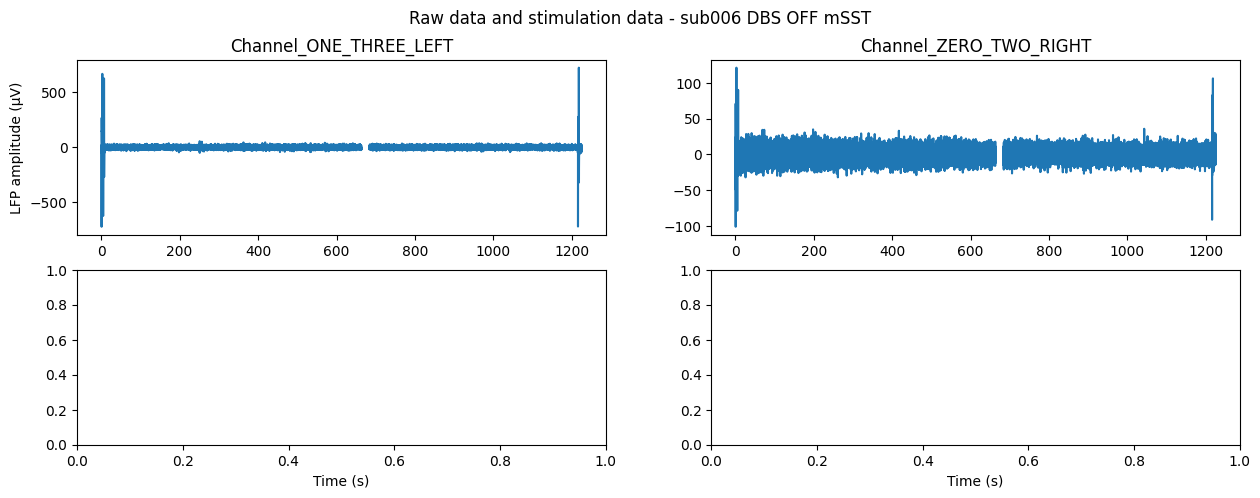

In [5]:
temp_save = join(saving_path, 'figures')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)
ephy_plotting.plot_raw_stim(
    session_ID = session_ID, 
    raw = raw, 
    ch_dict = ch_dict,
    saving_path = temp_save
    )

## 2.2. Plot full session PSD ##

Effective window size : 1.000 (s)
Effective window size : 1.000 (s)


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished


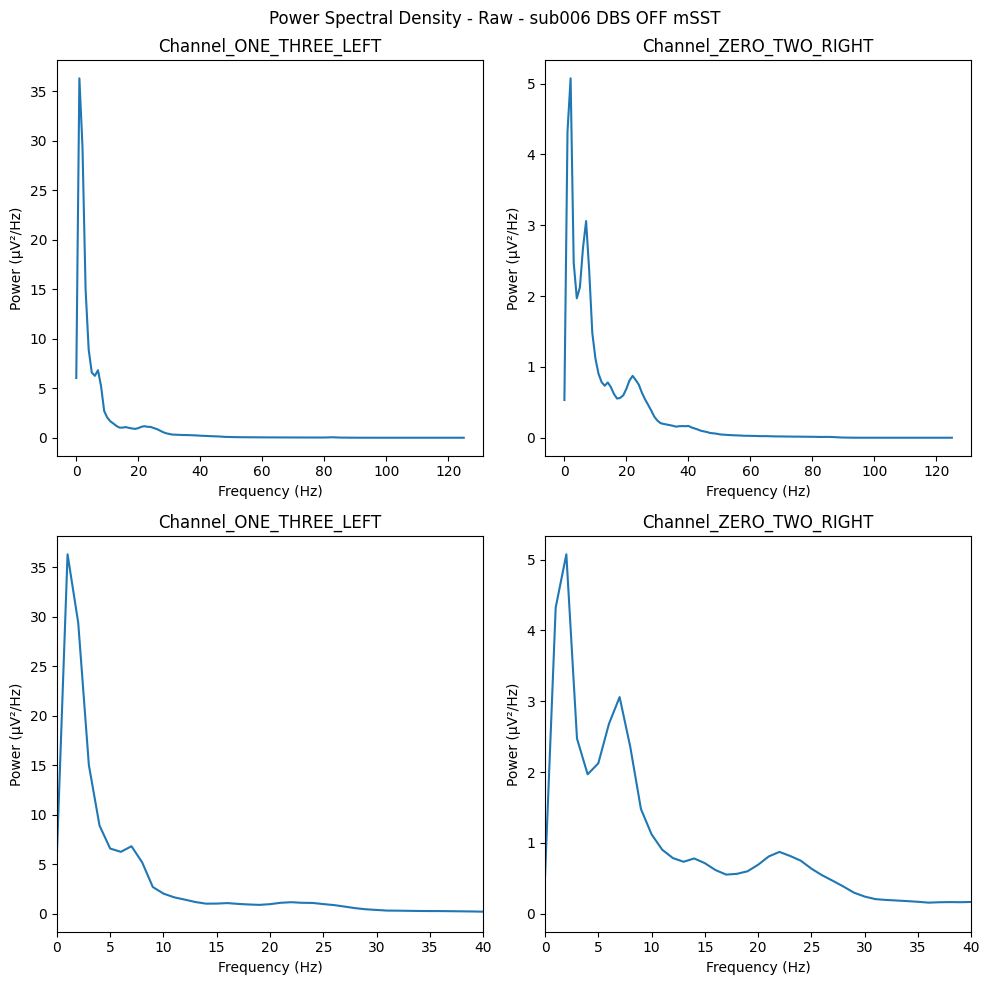

In [ ]:
temp_save = join(saving_path, 'figures')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

psd_left, freqs_left, psd_right, freqs_right = analysis.compute_psd_welch(
    raw = raw,
    start_time = 10,
    end_time = -10,
    ch_dict = ch_dict
    )

# Compute band power for theta, alpha, low-beta and high-beta ranges:
band_metrics_left = utils.compute_band_metrics(psd_left, freqs_left)
band_metrics_right = utils.compute_band_metrics(psd_right, freqs_right)

ephy_plotting.plot_psd_log(
    session_ID = session_ID, 
    raw = raw, 
    freqs_left = freqs_left, 
    psd_left = psd_left, 
    freqs_right = freqs_right, 
    psd_right = psd_right, 
    saving_path = temp_save, 
    is_filt = False
    )

In [19]:
temp_save = join(saving_path, 'power values from psd')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)
band_metrics_df = pd.DataFrame({
    'session_ID': [session_ID],
    'left_theta_power (uV2)': [band_metrics_left['theta']],
    'left_alpha_power (uV2) ': [band_metrics_left['alpha']],
    'left_low_beta_power (uV2) ': [band_metrics_left['low-beta']],
    'left_high_beta_power (uV2) ': [band_metrics_left['high-beta']],
    'right_theta_power (uV2) ': [band_metrics_right['theta']],
    'right_alpha_power (uV2) ': [band_metrics_right['alpha']],
    'right_low_beta_power (uV2) ': [band_metrics_right['low-beta']],
    'right_high_beta_power (uV2) ': [band_metrics_right['high-beta']]
})
band_metrics_df.to_csv(join(temp_save, f'{session_ID}_band_metrics.csv'), index=False)
band_metrics_df

,session_ID,left_theta_power (uV2),left_alpha_power (uV2),left_low_beta_power (uV2),left_high_beta_power (uV2),right_theta_power (uV2),right_alpha_power (uV2),right_low_beta_power (uV2),right_high_beta_power (uV2)
0,sub006 DBS OFF mSST,32.678911,5.767085,5.00272,9.263486,9.541689,3.159098,3.138135,6.269151


## 2.3. Plot full session TFR with overlapped stimulation if available ##

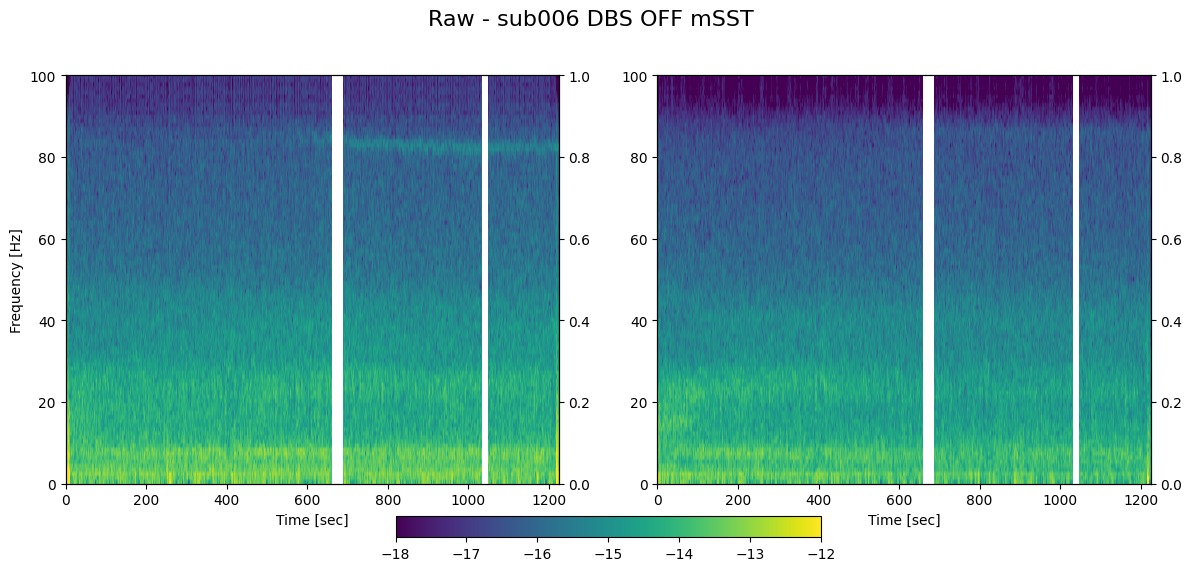

In [6]:
temp_save = join(saving_path, 'figures')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)
ephy_plotting.plot_stft_stim(
    session_ID = session_ID, 
    raw = raw, 
    saving_path = temp_save, 
    ch_dict = ch_dict,
    is_filt = False, 
    vmin = -18, 
    vmax = -12, 
    fmin = 0, 
    fmax = 100,
    save_as = 'png'
    )

# 3. Create epochs #

In [34]:
raw.ch_names

['Channel_ONE_THREE_LEFT',
 'Channel_ZERO_TWO_RIGHT',
 'RAW_Left_STN',
 'RAW_Right_STN']

In [38]:
ch_dict

{'left_LFP': 0, 'right_LFP': 1, 'left_stim': None, 'right_stim': None}

In [39]:
# Rename channels to match between subjects and sessions, to make plotting easier later on
# Rename channels to be consistent across subjects, these are acceptable channel names, 
# only keep the ones that are present in the raw data:

# Filter the data to remove high-frequency noise/stim artifact as we areinterested in signal below 80Hz mostly
filtered_data = raw.copy().filter(l_freq=0, h_freq=80)

# Extract events and create epochs
# only keep lfp channels
filtered_data_lfp = filtered_data.copy().pick_channels([filtered_data.ch_names[ch_dict['left_LFP']], filtered_data.ch_names[ch_dict['right_LFP']]])

new_channel_names = [
    "Left_STN",
    "Right_STN"
]

# Get the existing channel names
old_channel_names = filtered_data_lfp.ch_names

# Create a mapping from old to new names
rename_dict = {old: new for old, new in zip(old_channel_names, new_channel_names)}

# Rename the channels
filtered_data_lfp.rename_channels(rename_dict)

mSST_raw_behav_session_data_path = join(
    onedrive_path, sub, "raw_data", 'BEHAVIOR', condition, 'mSST'
    )
for filename in os.listdir(mSST_raw_behav_session_data_path):
    if filename.endswith(".csv"):
        fname = filename
filepath_behav = join(mSST_raw_behav_session_data_path, fname)
df = pd.read_csv(filepath_behav)

# return the index of the first row which is not filled by a Nan value:
start_task_index = df['blocks.thisRepN'].first_valid_index()
stop_task_index = df['blocks.thisRepN'].last_valid_index()
df_maintask = df.iloc[start_task_index:stop_task_index + 1]


# remove all useless columns to clean up dataframe
column_names = df_maintask.columns
columns_to_keep = [i for i in [
'blocks.thisN', 'trial_loop.thisN', 'trial_type', 
'continue_signal_time', 'stop_signal_time', 
'fixation_cross.started', 'go_rectangle.started',
'key_resp_experiment.keys', 'key_resp_experiment.corr', 'key_resp_experiment.rt',
'early_press_resp.keys', 'early_press_resp.rt', 'early_press_resp.corr',
'late_key_resp1.keys', 'late_key_resp1.rt', 
'late_key_resp2.keys', 'late_key_resp2.rt'
] if i in column_names]

mini_df_maintask = df_maintask[columns_to_keep]

# remove the trials with early presses, as in these trials the cues were not presented (for mSST)
early_presses = mini_df_maintask[mini_df_maintask['early_press_resp.corr'] == 1]
early_presses_trials = list(early_presses.index)
number_early_presses = len(early_presses_trials)

# remove trials with early presses from the dataframe:
df_maintask_copy = mini_df_maintask.drop(early_presses_trials).reset_index(drop=True)

# First generate global epochs (without taking into account success outcome)
# events and event_id used for epochs creation
events, event_id = mne.events_from_annotations(filtered_data_lfp)
epochs, filtered_event_dict = preprocessing.create_epochs(
    filtered_data_lfp, 
    sub, 
    keys_to_keep = ['GC', 'GF', 'GO', 'GS', 'continue', 'stop'],  # here we could remove the continue and stop events, but let's keep them for consistency with how EEG was epoched
    tmin = -3.5,
    tmax = 3.5,
    baseline = None
    )
n_epochs = len(epochs)

# inverse mapping (event code -> label)
inv_event_id = {v: k for k, v in event_id.items()}

metadata = pd.DataFrame(index=np.arange(len(epochs)))
metadata["event"] = [inv_event_id[e] for e in epochs.events[:, 2]]
metadata["sample"] = epochs.events[:, 0]
metadata["event_timing"] = epochs.events[:, 0] / raw.info['sfreq']  # in seconds
metadata["trial_type"] = np.nan

# LFP -> behavioral naming mapping
mapping = {
    "GC": "go_continue_trial",
    "GO": "go_trial",
    "GF": "go_fast_trial",
    "GS": "stop_trial",
    }

trial_mask = metadata["event"].isin(mapping.keys())

assert trial_mask.sum() == len(df_maintask_copy), \
    f"Mismatch: {trial_mask.sum()} LFP trials vs {len(df_maintask_copy)} behavioral trials"

# fill directly from behavioral file
for col in df_maintask_copy.columns:
    metadata.loc[trial_mask, col] = df_maintask_copy[col].values

for i in metadata.index:
    if metadata.loc[i, "event"] == "continue":
        # find the last GC before this
        prev_idx = metadata.loc[:i-1][metadata["event"] == "GC"].index[-1]
        metadata.loc[i, df_maintask_copy.columns] = metadata.loc[prev_idx, df_maintask_copy.columns]

    elif metadata.loc[i, "event"] == "stop":
        # find the last GS before this
        prev_idx = metadata.loc[:i-1][metadata["event"] == "GS"].index[-1]
        metadata.loc[i, df_maintask_copy.columns] = metadata.loc[prev_idx, df_maintask_copy.columns]

epochs.metadata = metadata

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 43 samples (0.172 s)



NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['GC', 'GF', 'GO', 'GS', 'continue', 'early', 'late', 'resp', 'stop']
Used Annotations descriptions: ['GC', 'GF', 'GO', 'GS', 'continue', 'early', 'late', 'resp', 'stop']
Not setting metadata
478 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 478 events and 1751 original time points ...


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.3s finished


0 bad epochs dropped


C:\Users\Juliette\AppData\Local\Temp\ipykernel_8580\3425412079.py:105: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  prev_idx = metadata.loc[:i-1][metadata["event"] == "GC"].index[-1]
C:\Users\Juliette\AppData\Local\Temp\ipykernel_8580\3425412079.py:110: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  prev_idx = metadata.loc[:i-1][metadata["event"] == "GS"].index[-1]


Adding metadata with 20 columns


# 4. Remove "bad" epochs manually #

In [36]:
cleaned_epochs = epochs.copy()

## 4.1. If NaN values in epochs, remove those first by indexing ##

In [ ]:
# Get the data: shape = (n_epochs, n_channels, n_times)
data_epochs = cleaned_epochs.get_data()

# Find epochs containing at least one NaN
nan_epochs = np.isnan(data_epochs).any(axis=(1, 2))

# Indices of epochs containing NaNs
nan_indices = np.where(nan_epochs)[0]

print(nan_indices)

[261 262 263 264 265 266 267 268 269 270 271 407 408 409 410 411 412 413]


You seem to have overlapping epochs. Some event lines may be duplicated in the plot.


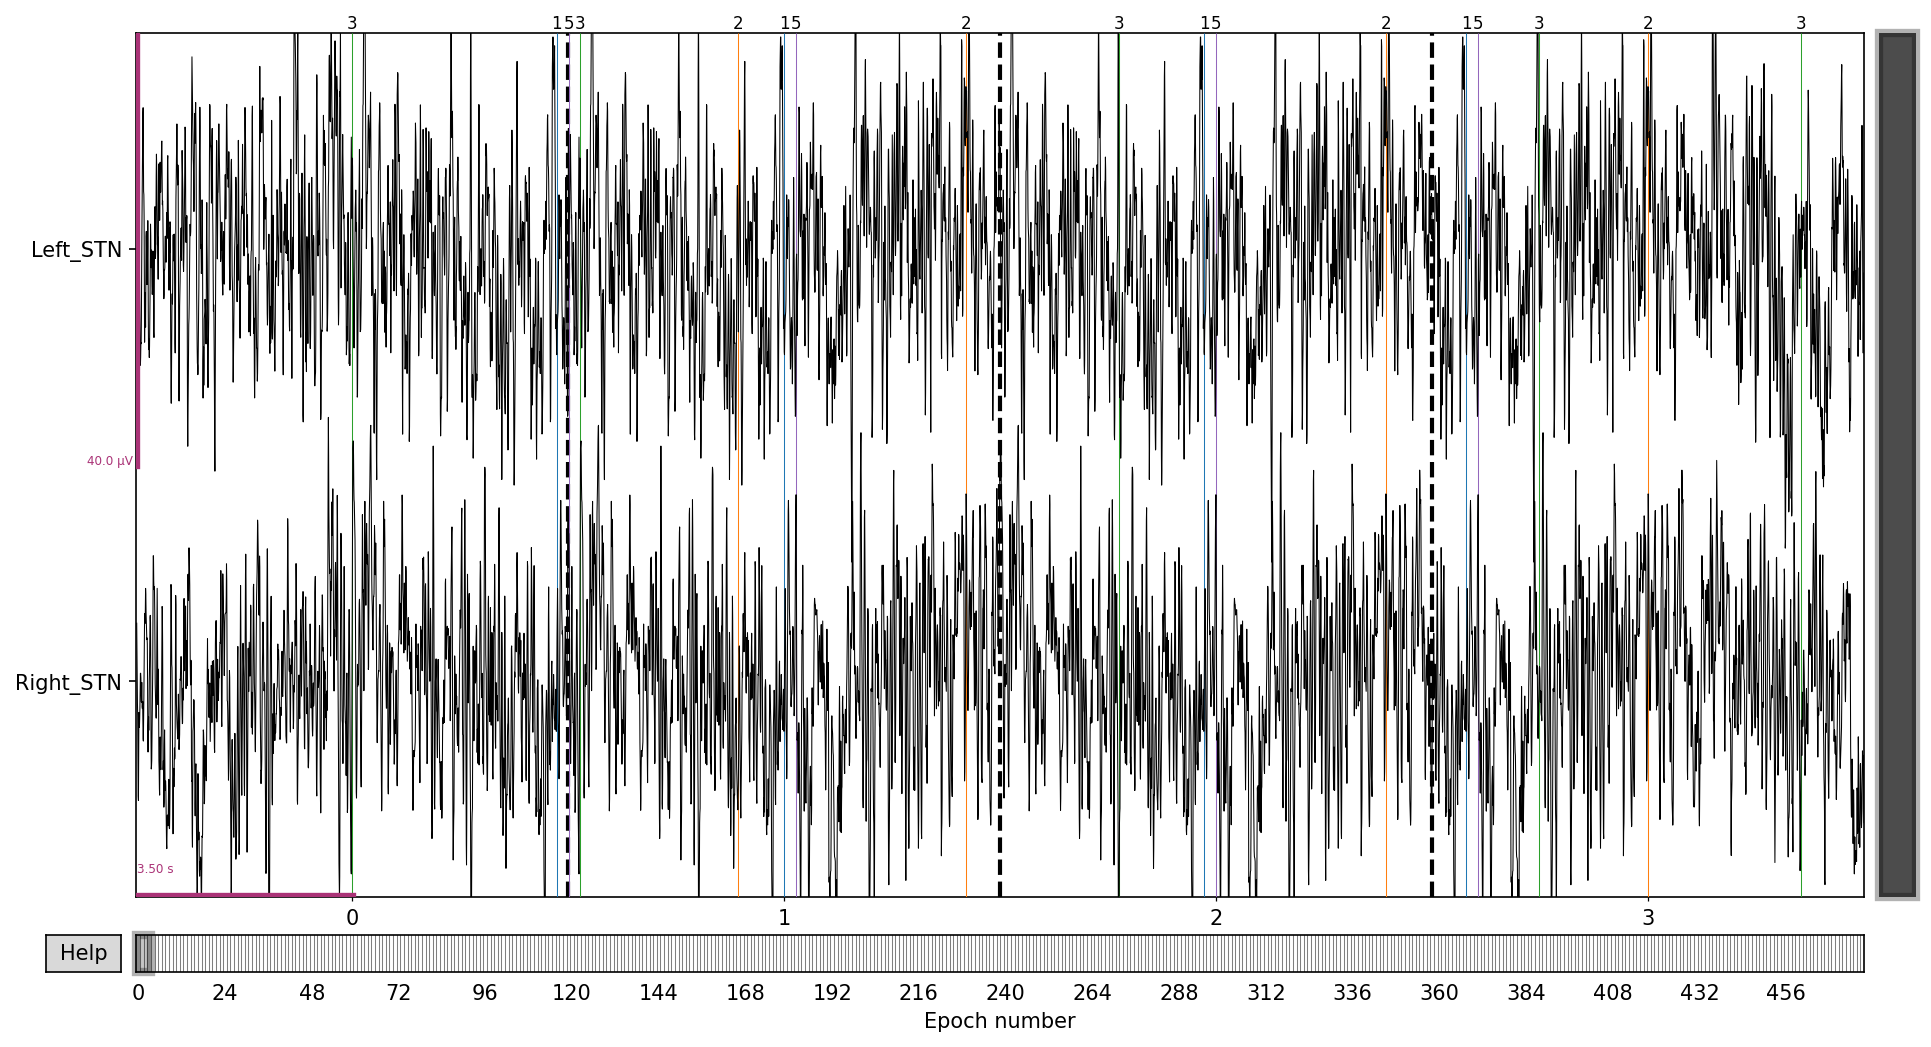

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [ ]:
%matplotlib qt
cleaned_epochs.plot(n_epochs=4, n_channels = len(cleaned_epochs.ch_names), events=True)

In [48]:
cleaned_epochs.drop(nan_indices)

Dropped 18 epochs: 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 407, 408, 409, 410, 411, 412, 413


<Epochs | 460 events (all good), -3.5 – 3.5 s (baseline off), ~12.3 MB, data loaded, with metadata,
 'GC': 57
 'GF': 58
 'GO': 172
 'GS': 58
 'continue': 57
 'stop': 58>

## 4.2. Dropped other "bad" epochs manually ##

You seem to have overlapping epochs. Some event lines may be duplicated in the plot.


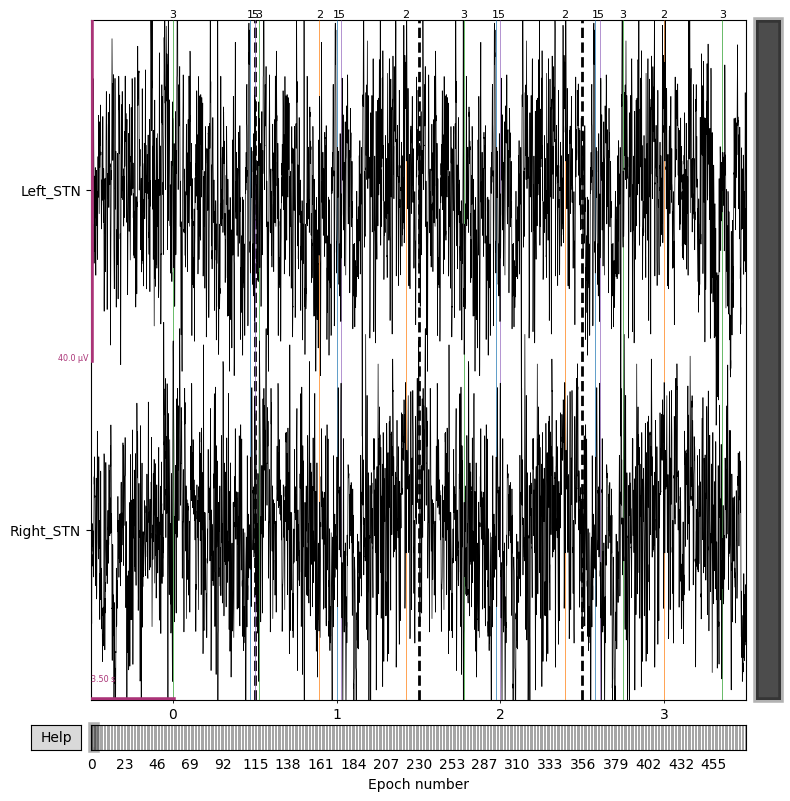

Dropped 4 epochs: 78, 79, 237, 238
The following epochs were marked as bad and are dropped:
[78, 79, 237, 238]
Channels marked as bad:
none


In [ ]:
%matplotlib qt
cleaned_epochs.plot(n_epochs=4, n_channels = len(cleaned_epochs.ch_names), events=True)

In [50]:
cleaned_epochs

<Epochs | 456 events (all good), -3.5 – 3.5 s (baseline off), ~12.2 MB, data loaded, with metadata,
 'GC': 57
 'GF': 57
 'GO': 170
 'GS': 58
 'continue': 57
 'stop': 57>

In [51]:
saving_path

'c:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\results\\lfp_epochs'

In [52]:
metadata_df = pd.DataFrame(cleaned_epochs.metadata)
# save both to csv (easier for later python import), and xlsx (easier to read in excel)
metadata_df.to_csv(os.path.join(saving_path, f"{session_ID}_cleaned-long-epo_metadata.csv"), index=True)
metadata_df.to_excel(os.path.join(saving_path, f"{session_ID}_cleaned-long-epo_metadata.xlsx"), index=True)

file_epoch = os.path.join(saving_path, f"{session_ID}_cleaned-long-epo.fif")
cleaned_epochs.save(file_epoch, overwrite=True)

Overwriting existing file.
Overwriting existing file.
